# XD Example
# Import Data and Functions

In [1]:
import numpy as np
from matplotlib import pyplot as plt

from astroML.density_estimation import XDGMM
from astroML.plotting.tools import draw_ellipse

from astroML.crossmatch import crossmatch
from astroML.datasets import fetch_sdss_S82standards, fetch_imaging_sample
from astroML.stats import sigmaG

## A. XD on a generated dataset

### A1. Generate true data (per comparar-la amb l'estimació XD)

Primero generamos una distribución de "datos verdaderos" usando números randomizados. Trazaremos este conjunto de datos como referencia para compararlo con el modelo derivado de la estimación con XD.
Los usuarios pueden cambiar el tamaño de la muestra (N) para experimentar la efectividad de este método: un tamaño de muestra más grande brinda más información sobre el conjunto de datos y es más fácil de converger; sin embargo, lleva más tiempo ejecutar el método. Es posible que el método no converja debido al pequeño tamaño de la muestra.

x_true:
[ 6.37883073  7.98514057  6.76379532  6.41889758  4.76100621  7.11698594
  5.08047587 10.14807452 11.06550173  4.61464236  8.89170035  6.0182378
  6.29020578 10.45985288  2.59962028  1.80897955  0.8837726   9.35031491
  8.71576626 10.17828015 11.17837919  9.13091712  5.57349783  8.58710866
  3.18680448  6.97134661  1.26490165 10.90109238  5.59910866  5.08800495
  3.45551134  8.94724948  5.60309216  6.34657403  1.35365493  6.72255109
  6.80509727  6.88592307 10.75867265  7.66412491  4.6628539   5.2586305
  7.68701122  1.09185819  7.70641481  7.39681049  3.01255261  2.42037996
  3.50667629  4.38478883  6.35956721  5.3399669  11.49375904  2.57575879
  3.73881405  3.15584481  7.32087081  3.69986804  5.39629901  3.40419417
  2.80159075  1.86013382  7.40728074  2.20786707  3.62521538  4.495943
  9.26094314  2.89668794  9.55417711  1.40046469 11.21482657  5.66897035
 11.02259475  6.88261404  7.92895053  1.22712029  3.87785253  1.61001798
  3.62041155  1.71515741  4.69365357  5.0093848

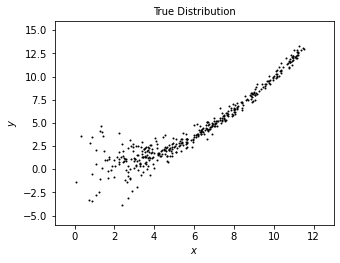

In [2]:
# Sample the dataset. 
# Here we use sample size = 400 in the example, 
# which converges in shorter time, and gives reasonable result.
N = 400
np.random.seed(0)

# generate the true data
x_true = (1.4 + 2 * np.random.random(N)) ** 2
y_true = 0.1 * x_true ** 2

# afegim dispersió a les dades "reals"
dx = 0.1 + 4. / x_true ** 2
dy = 0.1 + 10. / x_true ** 2


#columnes de dades a plotejar
x_true += np.random.normal(0, dx, N)
y_true += np.random.normal(0, dy, N)

print('x_true:')
print(x_true)
print('y_true:')
print(y_true)

# define a function to plot all distributions in the same format
def plot_distribution(text, sample_x, sample_y):
    plt.figure(figsize=(5, 3.75))
    plt.scatter(sample_x, sample_y, s=4,lw=0,c='k')
    plt.xlim(-1, 13)
    plt.ylim(-6, 16)
    plt.xlabel('$x$')
    plt.ylabel('$y$')
    plt.title(text,fontsize=10)

# plot true distribution
plot_distribution('True Distribution', x_true, y_true)

plt.show()

### A2. Generate noisy data¶
Agregamos algo de radom ruidoso a los datos verdaderos para modelar lo que podemos observar a partir de la distribución verdadera.

x_dim: (400,)
x_noisy:
[ 7.17139592  7.42450495  6.35606753  6.51299355  5.14495871  6.94827572
  5.23519934  9.94606865 10.61556611  5.2835463  10.5560486   6.61622708
  6.38829584 11.65353959  2.75234565  1.51844269  1.15638242  9.29944231
  8.36192537  9.91037763 11.60808951  7.98332215  5.69923463  7.73744102
  2.29286328  5.77785448  1.97438514 10.81532     5.63871038  5.47151571
  3.97533206  8.09114232  5.8020552   6.41024446  1.27881979  6.73902694
  7.48798501  6.28160514 10.945384    7.65832058  3.9669792   4.95625365
  7.76219717  1.77806272  8.08664681  7.78510834  2.44867745  2.80802509
  3.57056217  4.12703346  6.31911192  5.62127284 11.49698427  3.12428033
  4.08196576  3.33487106  6.75066207  3.77214765  5.42335514  4.28830775
  1.67904931  1.79348689  7.27717078  2.30806077  2.64437162  5.05411725
  9.26899928  2.14673748  9.35374879  1.76275755 10.64408546  5.6711925
 10.46760271  6.52650617  7.94173065  1.33183398  3.60234011  1.78846069
  3.84549844  1.58151795  5.2

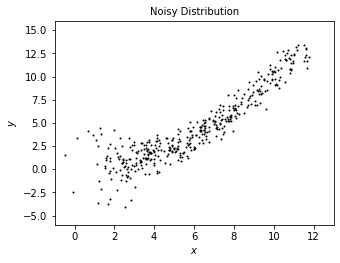

In [3]:
# afegim soroll per obtenir dades "experimentals"
dx = 0.2 + 0.5 * np.random.random(N)
dy = 0.2 + 0.5 * np.random.random(N)

x = x_true + np.random.normal(0, dx)  #dim = 400x1
y = y_true + np.random.normal(0, dy)

print('x_dim:', x.shape)
print('x_noisy:')
print(x)
print('y_dim:', y.shape)
print('y_noisy:')
print(y)

# plot noisy distribution
plot_distribution('Noisy Distribution', x, y)

### A3. Compute extreme deconvolution (XD) (sobre les dades noisy)
El siguiente código calcula el resultado. En el método XDGMM, n_components (integer) define el número de componentes gaussianos que se ajustan a los datos.
max_iter (integer) define el número de iteraciones EM a realizar (predeterminado como 100). Un número de iteración más grande generalmente contribuye a una mejor aproximación a los datos verdaderos, pero lleva más tiempo ejecutarlo.
Se espera que esta celda se ejecute en un poco más de 1 minuto.

In [4]:
# stack the results for computation
X = np.vstack([x, y]).T   #vertical stack (concatenació vertical) de les dades noisy i transposició
Xerr = np.zeros(X.shape + X.shape[-1:])

# X.shape: (400, 2)
# X.shape[-1:] : (2,)
# X.shape + X.shape[-1:] : (400, 2, 2)
# Xerr = np.zeros(400, 2, 2)

diag = np.arange(X.shape[-1]) #[0 1]
Xerr[:, diag, diag] = np.vstack([dx ** 2, dy ** 2]).T

print('X dim:', X.shape)
print('Xerr dim:', Xerr.shape)
print('Posicions de les estrelles:')
print('X:\tx\t    y')
print(X)
print('Xerr:')
print(Xerr)


clf = XDGMM(n_components=10, max_iter=200)
'''n_components: nombre de components gaussians que s'ajusten a les dades'''
   
clf.fit(X, Xerr)
sample = clf.sample(N)

X dim: (400, 2)
Xerr dim: (400, 2, 2)
Posicions de les estrelles:
X:	x	    y
[[ 7.17139592  4.29940251]
 [ 7.42450495  5.89814693]
 [ 6.35606753  4.07741713]
 [ 6.51299355  4.23772385]
 [ 5.14495871  2.13923388]
 [ 6.94827572  5.21744504]
 [ 5.23519934  3.27639463]
 [ 9.94606865 10.44478623]
 [10.61556611 11.79665537]
 [ 5.2835463   1.77720381]
 [10.5560486   9.43054175]
 [ 6.61622708  3.22916593]
 [ 6.38829584  3.81898961]
 [11.65353959 10.93457039]
 [ 2.75234565  1.10499758]
 [ 1.51844269  0.38486927]
 [ 1.15638242 -3.60237762]
 [ 9.29944231  8.47745944]
 [ 8.36192537  7.30384648]
 [ 9.91037763 10.30887407]
 [11.60808951 12.34790528]
 [ 7.98332215  8.04049065]
 [ 5.69923463  1.18127888]
 [ 7.73744102  6.80333267]
 [ 2.29286328 -0.08305626]
 [ 5.77785448  5.11508302]
 [ 1.97438514  4.2643635 ]
 [10.81532    10.78336917]
 [ 5.63871038  3.46945779]
 [ 5.47151571  1.86912743]
 [ 3.97533206  0.47260355]
 [ 8.09114232  7.6611981 ]
 [ 5.8020552   2.36858672]
 [ 6.41024446  3.16829913]
 [ 1.

### A4. Plot the result from XD
Usamos puntos dispersos para mostrar el resultado de datos ruidosos de la corrección XD. El gráfico muestra una distribución menos dispersa que los datos ruidosos e incluso que los datos verdaderos, lo que retrata mejor una "distribución subyacente".

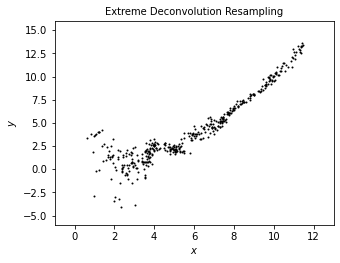

In [5]:
# plot noisy distribution
#                                                          x              y
plot_distribution('Extreme Deconvolution Resampling', sample[:, 0], sample[:, 1])

### A5. Use subplots to show clear comparison
Trazamos la distribución verdadera (arriba a la izquierda), la distribución ruidosa (arriba a la derecha) y la distribución remuestreada de XD (abajo a la izquierda) juntas para mostrar una comparación clara de la efectividad de este método en el modelado.
Además, agregamos una representación agrupada de la distribución (abajo a la derecha) para mostrar el uso en la localización de agrupaciones con el método XD.

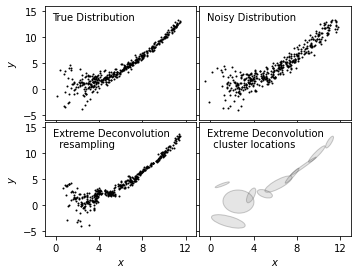

In [6]:
# Plot the results
fig = plt.figure(figsize=(5, 3.75))
fig.subplots_adjust(left=0.1, right=0.95,
                    bottom=0.1, top=0.95,
                    wspace=0.02, hspace=0.02)

ax1 = fig.add_subplot(221)
ax1.scatter(x_true, y_true, s=4, lw=0, c='k')

ax2 = fig.add_subplot(222)
ax2.scatter(x, y, s=4, lw=0, c='k')

ax3 = fig.add_subplot(223)
ax3.scatter(sample[:, 0], sample[:, 1], s=4, lw=0, c='k')

ax4 = fig.add_subplot(224)
for i in range(clf.n_components):
    draw_ellipse(clf.mu[i], clf.V[i], scales=[2], ax=ax4,
                 ec='k', fc='gray', alpha=0.2)

titles = ["True Distribution", "Noisy Distribution",
          "Extreme Deconvolution\n  resampling",
          "Extreme Deconvolution\n  cluster locations"]

ax = [ax1, ax2, ax3, ax4]

for i in range(4):
    ax[i].set_xlim(-1, 13)
    ax[i].set_ylim(-6, 16)

    ax[i].xaxis.set_major_locator(plt.MultipleLocator(4))
    ax[i].yaxis.set_major_locator(plt.MultipleLocator(5))

    ax[i].text(0.05, 0.95, titles[i],
               ha='left', va='top', transform=ax[i].transAxes)

    if i in (0, 1):
        ax[i].xaxis.set_major_formatter(plt.NullFormatter())
    else:
        ax[i].set_xlabel('$x$')

    if i in (1, 3):
        ax[i].yaxis.set_major_formatter(plt.NullFormatter())
    else:
        ax[i].set_ylabel('$y$')

## B. XD on real star sample
En esta sección, usamos un conjunto de estrellas estándar de S82 (SNR alta) y un conjunto de estrellas ruidosas de una sola época (SNR baja). Realizaremos XD en los datos ruidosos y veremos cómo vuelve a muestrear los datos en grupos.

### B1. Perform extinction correction on noisy sample
Primero, arreglamos el verdadero color de la estrella de la extinción del polvo en una muestra de datos ruidosa. Aplicamos la curva de corrección de extinción definida como 𝐶𝜆≡𝐴𝜆𝐴, donde el valor de 𝐶𝜆para cada banda de S82 es de Berry et al 2012 .

In [7]:
# define u-g-r-i-z extinction from Berry et al, arXiv 1111.4985 multiply extinction by A_r
extinction_vector = np.array([1.810, 1.400, 1.0, 0.759, 0.561])

# Fetch and process the noisy imaging data (obtenir i processar les dades d'imatges amb soroll)
data_noisy = fetch_imaging_sample()

# select only stars (seleccionem només les estrelles)
data_noisy = data_noisy[data_noisy['type'] == 6]

# Get the extinction-corrected magnitudes for each band
X = np.vstack([data_noisy[f + 'RawPSF'] for f in 'ugriz']).T
Xerr = np.vstack([data_noisy[f + 'psfErr'] for f in 'ugriz']).T
print('Magnituds u-g-r-i-z (columnes) per cada estrella (files),\t', X.shape)
print(X)
print("Matriu d'errors,\t\t\t", Xerr.shape)
print(Xerr)

# extinction terms from Berry et al, arXiv 1111.4985
X -= (extinction_vector * data_noisy['rExtSFD'][:, None])

Magnituds u-g-r-i-z (columnes) per cada estrella (files),	 (82003, 5)
[[24.989 22.347 20.617 18.896 17.976]
 [23.02  22.333 20.907 19.93  19.515]
 [20.804 19.544 18.981 18.803 18.707]
 ...
 [24.841 23.122 22.235 20.45  19.665]
 [24.458 21.254 19.818 18.602 17.951]
 [21.005 20.024 19.557 19.425 19.357]]
Matriu d'errors,			 (82003, 5)
[[0.793 0.094 0.038 0.035 0.038]
 [0.382 0.102 0.045 0.035 0.07 ]
 [0.065 0.022 0.017 0.019 0.036]
 ...
 [0.713 0.157 0.11  0.04  0.077]
 [0.721 0.04  0.024 0.021 0.028]
 [0.07  0.025 0.021 0.023 0.059]]


In [8]:
#np.load('sdss_S82standards.npy')

### B2. Perform extinction correction on standard sample
A continuación, apilamos el conjunto de estrellas S82 y realizamos la misma corrección de extinción en los datos.

In [9]:
#Obtener y procesar los datos de imágenes apilados

data_stacked = fetch_sdss_S82standards()    #(1006849 estrelles , 36 magnituds)
#print('data_stacked:', data_stacked.shape)
#print(data_stacked)


# apliquem cuts sobre les columnes RA i DEC

RA = data_stacked['RA']     # columna RA
DEC = data_stacked['DEC']   # columna DEC
data_stacked = data_stacked[(RA > 0) & (RA < 10) &
                            (DEC > -1) & (DEC < 1)]  # sample de (40614 estrelles, 36 magnituds)
#print('RA:', RA.shape)
#print(RA)
#print('DEC:', DEC.shape)
#print(DEC)
#print('data_stacked:', data_stacked.shape)
#print(data_stacked)


# obtenim les 5 magnituds per cada estrella
Y = np.vstack([data_stacked['mmu_' + f] for f in 'ugriz']).T   #(40614 estrelles, 5 magnituds)
Yerr = np.vstack([data_stacked['msig_' + f] for f in 'ugriz']).T 

#print('Y:', Y.shape)
#print(Y)
#print('Yerr:', Yerr.shape)
#print(Yerr)

# extinction terms from Berry et al, arXiv 1111.4985
Y -= (extinction_vector * data_stacked['A_r'][:, None])  #(40614 estrelles, 5 magnituds)
#print('Y:', Y.shape)
#print(Y)


# quality cuts
g = Y[:, 1]   # columna magnitud g
mask = ((Yerr.max(1) < 0.05) &   # [ True False False ...  True False False]   
        (g < 20))    
'''   mask: array de booleans (True: si es compleix la condició:
                              error màxim en g de 0.05 i g < 20     '''
#print('g:', g.shape) 
#print(g)
#print('mask:', mask.shape)
#print(mask)


#filtrem amb màscara, ens queden unes 13000 estrelles
data_stacked = data_stacked[mask]                        # (13377 estrelles, 36 magnituds)
Y = Y[mask]                                              # (13377 estrelles, 5 magnituds)
Yerr = Yerr[mask]

print('data_stacked:', data_stacked.shape)
print(data_stacked)
print('Y:', Y.shape)
print(Y)
print('Yerr:', Yerr.shape)
print(Yerr)


data_stacked: (13377,)
[(2.0100000e-04, -0.838723 , 0.045, 0.038, 21, 0.123, 20, 19.835, 19.834, 0.01 , 0.046, 1.1, 20, 18.846, 18.849, 0.005, 0.028, 1.2, 20, 18.473, 18.47 , 0.004, 0.022, 1.5, 20, 18.313, 18.314, 0.004, 0.019, 1. , 20, 18.241, 18.244, 0.007, 0.035, 1. )
 (1.9310000e-03,  0.5253029, 0.038, 0.032,  9, 0.071,  9, 18.86 , 18.86 , 0.008, 0.035, 2.1,  9, 17.557, 17.553, 0.007, 0.012, 0.4,  9, 17.035, 17.031, 0.006, 0.013, 0.6,  9, 16.85 , 16.855, 0.006, 0.018, 0.9,  9, 16.788, 16.79 , 0.006, 0.019, 0.9)
 (1.2230000e-03,  0.665145 , 0.022, 0.05 ,  5, 0.075,  5, 16.533, 16.531, 0.006, 0.016, 1.3,  5, 15.197, 15.2  , 0.009, 0.012, 0.4,  5, 14.709, 14.707, 0.009, 0.017, 0.7,  5, 14.563, 14.556, 0.007, 0.031, 2.8,  5, 14.487, 14.494, 0.007, 0.018, 1.8)
 ...
 (9.4993010e+00, -0.49802  , 0.042, 0.018,  5, 0.06 ,  5, 17.397, 17.397, 0.008, 0.012, 0.5,  5, 16.338, 16.343, 0.009, 0.017, 0.8,  5, 15.914, 15.922, 0.008, 0.028, 2.2,  5, 15.768, 15.765, 0.008, 0.009, 0.2,  5, 15.715, 15.

Aplicant cuts hem arribat a un sample de **13377 estrelles** .

### B3. Cross-match two data sets (cal fer-ho jo?)
Usamos la coincidencia cruzada para hacer coincidir la muestra ruidosa con la muestra estándar y hacer que dos conjuntos sean comparables.

In [10]:
Xlocs = np.hstack((data_noisy['ra'][:, np.newaxis],  #noisy points   #(82003, 2) 
                   data_noisy['dec'][:, np.newaxis]))

Ylocs = np.hstack((data_stacked['RA'][:, np.newaxis],  #stacked points    #(13377, 2)
                   data_stacked['DEC'][:, np.newaxis]))

print("number of noisy points:  ", Xlocs.shape)      #(82003, 2)
print("number of stacked points:", Ylocs.shape)      #(13377, 2)

# find all points within 0.9 arcsec.  This cutoff was selected
# by plotting a histogram of the log(distances).
dist, ind = crossmatch(Xlocs, Ylocs, max_distance=0.9 / 3600)

noisy_mask = (~np.isinf(dist))
stacked_mask = ind[noisy_mask]

# select the data
data_noisy = data_noisy[noisy_mask]
X = X[noisy_mask]                 # (12313, 5)
Xerr = Xerr[noisy_mask]

data_stacked = data_stacked[stacked_mask]
Y = Y[stacked_mask]              #  (12313, 5)
Yerr = Yerr[stacked_mask]

# double-check that our cross-match succeeded
assert X.shape == Y.shape
print("size after crossmatch:", X.shape)     #(12313, 5) punts després del cross-match (testejar compatibilitat)

number of noisy points:   (82003, 2)
number of stacked points: (13377, 2)
size after crossmatch: (12313, 5)


### B4. Define W matrix and calculate covariance

In [11]:
# first define mixing matrix W    #(5,5)
W = np.array([[0, 1, 0, 0, 0],    # g magnitude
              [1, -1, 0, 0, 0],   # u-g color
              [0, 1, -1, 0, 0],   # g-r color
              [0, 0, 1, -1, 0],   # r-i color
              [0, 0, 0, 1, -1]])  # i-z color

''' u-g-r-i-z:
    u = [1, 0, 0, 0, 0]
    g = [0, 1, 0, 0, 0]
    r = [0, 0, 1, 0, 0]
    i = [0, 0, 0, 1, 0]
    z = [0, 0, 0, 0, 1]  '''

X = np.dot(X, W.T)   #(12313, 5)
Y = np.dot(Y, W.T)   #(12313, 5)

# compute error covariance from mixing matrix
Xcov = np.zeros(Xerr.shape + Xerr.shape[-1:])
Xcov[:, range(Xerr.shape[1]), range(Xerr.shape[1])] = Xerr ** 2

# each covariance C = WCW^T
# best way to do this is with a tensor dot-product
Xcov = np.tensordot(np.dot(Xcov, W.T), W, (-2, -1))


print('X: data_noisy', X.shape)   #(12313, 5)
print(X,'\n')
print('Y: data_stacked', Y.shape)   #(12313, 5)
print(Y,'\n')
print('Xcov: "error"', Xcov.shape)   #(12313, 5, 5)
print(Xcov)

X: data_noisy (12313, 5)
[[19.3872    1.21408   0.5182    0.151008  0.073824]
 [17.1034    1.23626   0.5294    0.209526  0.121428]
 [14.9342    1.33108   0.5782    0.214008  0.138824]
 ...
 [19.0198    1.97207   0.7858    0.310407  0.154546]
 [16.9814    2.33066   0.9704    0.412166  0.243348]
 [19.9176    0.94984   0.4366    0.113684  0.052952]] 

Y: data_stacked (12313, 5)
[[19.36919975  1.09607887  0.48419952  0.19300842  0.06682396]
 [17.09140015  1.24925995  0.50740051  0.20752716  0.09342575]
 [14.93419933  1.36807919  0.53520012  0.24800682  0.10382462]
 ...
 [19.02480125  1.99106979  0.79480171  0.30140686  0.13954544]
 [16.99139977  2.36966133  0.98740005  0.40816498  0.20334911]
 [19.86059952  0.89583969  0.38059998  0.12568283  0.05995369]] 

Xcov: "error" (12313, 5, 5)
[[[ 0.000484 -0.000484  0.000484  0.        0.      ]
  [-0.000484  0.004709 -0.000484  0.        0.      ]
  [ 0.000484 -0.000484  0.000773 -0.000289  0.      ]
  [ 0.        0.       -0.000289  0.00065  -0.

### B5. Plot two raw data sets
Elegimos el diez por ciento de los puntos en cada conjunto de datos para graficar en comparación. Como podemos ver en el resultado, antes de XD, la época sigle (derecha) tiene más ruido que las estrellas estándar (izquierda).

X: [[19.3872    1.21408   0.5182    0.151008  0.073824]
 [17.1034    1.23626   0.5294    0.209526  0.121428]
 [14.9342    1.33108   0.5782    0.214008  0.138824]
 ...
 [19.0198    1.97207   0.7858    0.310407  0.154546]
 [16.9814    2.33066   0.9704    0.412166  0.243348]
 [19.9176    0.94984   0.4366    0.113684  0.052952]]
X_sample: [[ 9.56767072  8.87149335]
 [10.15027382 10.07559314]
 [ 9.81407381  9.9115393 ]
 ...
 [ 4.65043984  2.32032304]
 [ 4.51930898  2.53583024]
 [ 4.80859002  2.56426251]]


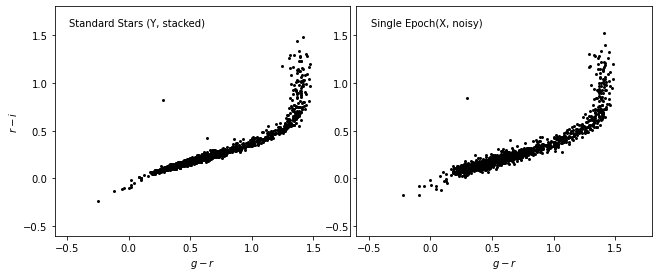

In [12]:
# Fit and sample from the underlying distribution
np.random.seed(42)
X_sample = clf.sample(X.shape[0])
print('X:', X)                       #(12313 estrelles, 5 magnituds)
print('X_sample:', X_sample)

# plot the results

fig = plt.figure(figsize=(10, 3.75))  #crea una figura d'un cert tamany
fig.subplots_adjust(left=0.12, right=0.95, #subplots
                    bottom=0.1, top=0.95,
                    wspace=0.02, hspace=0.02)

# only plot 1/10 of the stars for clarity

#subplot 1 (esquerra)
ax1 = fig.add_subplot(121)
ax1.scatter(Y[::10, 2], Y[::10, 3], s=9, lw=0, c='k')
ax1.set_ylabel('$r-i$')  #un títol per l'eix y

#subplot 2 (dreta)
ax2 = fig.add_subplot(122)
ax2.scatter(X[::10, 2], X[::10, 3], s=9, lw=0, c='k')

titles = ["Standard Stars (Y, stacked)", "Single Epoch(X, noisy)"]  #títols dels gràfics
ax = [ax1, ax2]

for i in range(2):  #pels dos gràfics
    ax[i].set_xlim(-0.6, 1.8)   #límits eixos
    ax[i].set_ylim(-0.6, 1.8)

    ax[i].xaxis.set_major_locator(plt.MultipleLocator(0.5))
    ax[i].yaxis.set_major_locator(plt.MultipleLocator(0.5))

    ax[i].text(0.05, 0.95, titles[i],
               ha='left', va='top', transform=ax[i].transAxes)

    ax[i].set_xlabel('$g-r$')  #dos títols per l'eix x

### B6. Calculate XD value
Definimos compute_XD y guardamos el resultado en un archivo pickle. Se estima que esta celda requiere un tiempo de ejecución prolongado (más de 20 minutos).

In [13]:
def compute_XD(n_clusters=12, rseed=0, max_iter=100, verbose=True):
    np.random.seed(rseed)
    clf = XDGMM(n_clusters, max_iter=max_iter, tol=1E-5, verbose=verbose)
    clf.fit(X, Xcov) #data_noisy
    return clf

clf = compute_XD(12)

/Applications/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:265: ConvergenceWarning: Initialization 1 did not converge. Try different init parameters, or increase max_iter, tol or check for degenerate data.
  warnings.warn('Initialization %d did not converge. '


1: log(L) = 32868
    (5.4 sec)
2: log(L) = 33422
    (5.4 sec)
3: log(L) = 33742
    (5.4 sec)
4: log(L) = 33967
    (5.4 sec)
5: log(L) = 34155
    (5.4 sec)
6: log(L) = 34307
    (5.4 sec)
7: log(L) = 34418
    (5.4 sec)
8: log(L) = 34507
    (5.4 sec)
9: log(L) = 34583
    (5.4 sec)
10: log(L) = 34648
    (5.4 sec)
11: log(L) = 34707
    (5.4 sec)
12: log(L) = 34762
    (5.4 sec)
13: log(L) = 34818
    (5.5 sec)
14: log(L) = 34884
    (5.4 sec)
15: log(L) = 34943
    (5.4 sec)
16: log(L) = 34988
    (5.4 sec)
17: log(L) = 35028
    (5.4 sec)
18: log(L) = 35066
    (5.4 sec)
19: log(L) = 35103
    (5.5 sec)
20: log(L) = 35138
    (5.4 sec)
21: log(L) = 35174
    (5.4 sec)
22: log(L) = 35208
    (5.6 sec)
23: log(L) = 35242
    (5.8 sec)
24: log(L) = 35276
    (5.4 sec)
25: log(L) = 35310
    (5.4 sec)
26: log(L) = 35342
    (5.4 sec)
27: log(L) = 35375
    (5.5 sec)
28: log(L) = 35406
    (5.5 sec)
29: log(L) = 35436
    (5.5 sec)
30: log(L) = 35465
    (5.5 sec)
31: log(L) = 35493


### B7. Plot results in comparison
Aquí graficamos el resultado de datos ruidosos después de XD en puntos dispersos (abajo a la izquierda), con una estimación de la ubicación del conglomerado en elipses, en comparación con los dos conjuntos de datos originales.
Después del remuestreo XD, los datos remuestreados se distribuyen menos dispersos que los datos ruidosos originales. También muestra un mejor patrón agrupado que la distribución estándar de estrellas.

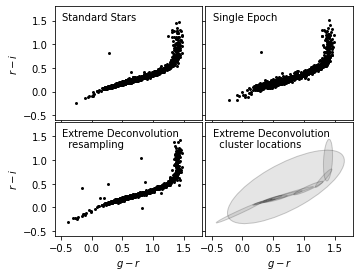

In [14]:
# Fit and sample from the underlying distribution
np.random.seed(42)
X_sample = clf.sample(X.shape[0])

# plot the results
fig = plt.figure(figsize=(5, 3.75))
fig.subplots_adjust(left=0.12, right=0.95,
                    bottom=0.1, top=0.95,
                    wspace=0.02, hspace=0.02)

# only plot 1/10 of the stars for clarity
ax1 = fig.add_subplot(221)
ax1.scatter(Y[::10, 2], Y[::10, 3], s=9, lw=0, c='k')

ax2 = fig.add_subplot(222)
ax2.scatter(X[::10, 2], X[::10, 3], s=9, lw=0, c='k')

ax3 = fig.add_subplot(223)
ax3.scatter(X_sample[::10, 2], X_sample[::10, 3], s=9, lw=0, c='k')

ax4 = fig.add_subplot(224)
for i in range(clf.n_components):
    draw_ellipse(clf.mu[i, 2:4], clf.V[i, 2:4, 2:4], scales=[2],
                 ec='k', fc='gray', alpha=0.2, ax=ax4)

titles = ["Standard Stars", "Single Epoch",
          "Extreme Deconvolution\n  resampling",
          "Extreme Deconvolution\n  cluster locations"]
ax = [ax1, ax2, ax3, ax4]

for i in range(4):
    ax[i].set_xlim(-0.6, 1.8)
    ax[i].set_ylim(-0.6, 1.8)

    ax[i].xaxis.set_major_locator(plt.MultipleLocator(0.5))
    ax[i].yaxis.set_major_locator(plt.MultipleLocator(0.5))

    ax[i].text(0.05, 0.95, titles[i],
               ha='left', va='top', transform=ax[i].transAxes)

    if i in (0, 1):
        ax[i].xaxis.set_major_formatter(plt.NullFormatter())
    else:
        ax[i].set_xlabel('$g-r$')

    if i in (1, 3):
        ax[i].yaxis.set_major_formatter(plt.NullFormatter())
    else:
        ax[i].set_ylabel('$r-i$')

### B8. Plot width of Locus
Trazamos los anchos de las estrellas estándar, una sola época y el resultado remuestreo XD en un gráfico.
En el eje x se muestra el ancho del lugar geométrico, también llamado color w, definido como 𝑤=−0.227𝑔+0.792𝑟−0.567𝑖+0.05.
𝜎𝐺del ajuste de la distribución gaussiana es el más pequeño en el resultado remuestreo de XD. Esto muestra la efectividad de corregir y agrupar datos ruidosos.

Text(0, 0.5, '$N(w)$')

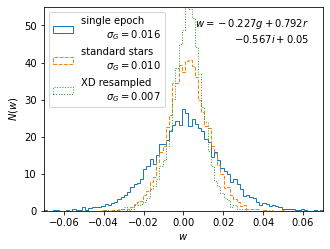

In [15]:
# Second figure: the width of the locus
fig = plt.figure(figsize=(5, 3.75))
ax = fig.add_subplot(111)

labels = ['single epoch', 'standard stars', 'XD resampled']
linestyles = ['solid', 'dashed', 'dotted']
for data, label, ls in zip((X, Y, X_sample), labels, linestyles):
    g = data[:, 0]
    gr = data[:, 2]
    ri = data[:, 3]

    r = g - gr
    i = r - ri

    mask = (gr > 0.3) & (gr < 1.0)
    g = g[mask]
    r = r[mask]
    i = i[mask]

    w = -0.227 * g + 0.792 * r - 0.567 * i + 0.05

    sigma = sigmaG(w)

    ax.hist(w, bins=np.linspace(-0.08, 0.08, 100), linestyle=ls,
            histtype='step', label=label + '\n\t' + r'$\sigma_G=%.3f$' % sigma,
            density=True)

ax.legend(loc=2)
ax.text(0.95, 0.95, '$w = -0.227g + 0.792r$\n$ - 0.567i + 0.05$',
        transform=ax.transAxes, ha='right', va='top')

ax.set_xlim(-0.07, 0.07)
ax.set_ylim(0, 55)

ax.set_xlabel('$w$')
ax.set_ylabel('$N(w)$')